In [1]:
!pip install datasets transformers

## PART-1

In [2]:
# 1) Libraries import karte hain
import torch
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

# 2) IMDb dataset fetch karna
def get_imdb_splits():
    """
    IMDb ka train/test split load karta hai.
    Returns a dict: {"train": Dataset, "test": Dataset}
    """
    return load_dataset("imdb", split=["train", "test"])

# 3) Tokenization function
def tokenize_texts(datasets, model_name="roberta-base", max_length=256):
    """
    AutoTokenizer initialize karke batched tokenization apply karta hai.
    Returns tokenized datasets.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    def _batch_tokenize(examples):
        return tokenizer(
            examples["text"],
            padding="max_length",
            truncation=True,
            max_length=max_length
        )
    
    # map per split
    return {
        split: ds.map(_batch_tokenize, batched=True)
        for split, ds in zip(["train", "test"], datasets)
    }

# 4) DataLoader banana
def make_dataloader(tokenized_ds, batch_size=8, shuffle=True):
    """
    Tokenized dataset se DataLoader return karta hai.
    """
    ds = tokenized_ds.remove_columns(["text"])
    ds.set_format("torch")
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

# 5) Workflow test karte hain
if __name__ == "__main__":
    # Step A: Load splits
    splits = get_imdb_splits()
    
    # Step B: Tokenize
    tok_splits = tokenize_texts(splits)
    
    # Step C: Create loaders
    train_loader = make_dataloader(tok_splits["train"], batch_size=16)
    test_loader  = make_dataloader(tok_splits["test"],  batch_size=32, shuffle=False)
    
    # Sanity check
    batch = next(iter(train_loader))
    print("Input IDs shape:", batch["input_ids"].shape)
    print("Attention mask shape:", batch["attention_mask"].shape)
    print("Labels shape:", batch["label"].shape)


Input IDs shape: torch.Size([16, 256])
Attention mask shape: torch.Size([16, 256])
Labels shape: torch.Size([16])


## PART-2

### Full fine-tune

In [4]:
import time
import numpy as np
import torch
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)


def init_full_model(model_name="roberta-base", num_labels=2):
    """
    Base model load karta hai sequence classification ke liye.
    """
    return AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )


def get_full_trainer(model, train_ds, eval_ds, output_dir="./ft_results"):
    """
    TrainingArguments aur Trainer object return karta hai.
    """
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        evaluation_strategy="epoch",
        logging_steps=100,
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy"
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = (preds == labels).mean()
        return {"accuracy": acc}

    return Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        compute_metrics=compute_metrics
    )


def run_full_fine_tune(tokenized_splits):
    """
    Train aur eval perform karta hai full fine-tuning ke liye.
    Prints metrics and resource usage.
    """
   
    model = init_full_model()
    
    trainer = get_full_trainer(
        model,
        train_ds=tokenized_splits["train"],
        eval_ds=tokenized_splits["test"]
    )

    
    start_time = time.time()
    trainer.train()
    duration = time.time() - start_time

    
    results = trainer.evaluate()

    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    gpu_mem = (
        torch.cuda.memory_allocated() / (1024**2)
        if torch.cuda.is_available() else None
    )

    
    print(f"✔️ Full FT Accuracy : {results['eval_accuracy']:.4f}")
    print(f"🔢 Trainable Params: {trainable}")
    print(f"⏱ Training Time    : {duration:.1f} sec")
    print(f"💾 GPU Mem (MB)    : {gpu_mem}")

# 5) Agar direct run karna ho:
if __name__ == "__main__":
    
    run_full_fine_tune(tok_splits)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.248100,0.243723,0.900400
2,0.191200,0.256761,0.929440
3,0.093500,0.294816,0.934200


✔️ Full FT Accuracy : 0.9342
🔢 Trainable Params: 124647170
⏱ Training Time    : 2353.5 sec
💾 GPU Mem (MB)    : 1488.55908203125


### LoRA fine-tune

In [3]:
# 1) Zaroori imports (agar pehle import na kiye hon)
import time
import numpy as np
import torch
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model
from peft import LoraConfig, get_peft_model

# 2) LoRA-enabled model initialise karne ka function
def init_lora_model(
    base_model="roberta-base",
    num_labels=2,
    lora_r=8,
    lora_alpha=16,
    lora_dropout=0.1
):
    """
    Base model load karke LoRA wrappers apply karta hai.
    """
    model = AutoModelForSequenceClassification.from_pretrained(
        base_model, num_labels=num_labels
    )
    cfg = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        target_modules=["query", "value"],
        lora_dropout=lora_dropout,
        bias="none",
        task_type="SEQ_CLS"
    )
    model = get_peft_model(model, cfg)
    return model

# 3) Trainer setup same as full FT, lekin output_dir alag rakhein
def get_lora_trainer(model, train_ds, eval_ds, output_dir="./lora_results"):
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        logging_steps=100,
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy"
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = (preds == labels).mean()
        return {"accuracy": acc}

    return Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        compute_metrics=compute_metrics
    )

# 4) LoRA fine-tuning run karne ka function
def run_lora_fine_tune(tokenized_splits):
    """
    LoRA ke saath train aur eval perform karta hai.
    """
    # Model load with LoRA
    model = init_lora_model()
    trainer = get_lora_trainer(
        model,
        train_ds=tokenized_splits["train"],
        eval_ds=tokenized_splits["test"]
    )

    start = time.time()
    trainer.train()
    tot_time = time.time() - start

    res = trainer.evaluate()
    # Trainable params
    tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
    # GPU memory
    gm = (
        torch.cuda.memory_allocated() / (1024**2)
        if torch.cuda.is_available() else None
    )

    # Results print karo
    print(f"✔️ LoRA Accuracy       : {res['eval_accuracy']:.4f}")
    print(f"🔢 LoRA Trainable P:   : {tp}")
    print(f"⏱ LoRA Train Time    : {tot_time:.1f} sec")
    print(f"💾 LoRA GPU Mem (MB)  : {gm}")

# 5) Direct run ke liye (agar notebook mein call karna ho)
if __name__ == "__main__":
    run_lora_fine_tune(tok_splits)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.205900,0.184618,0.930400
2,0.196300,0.184422,0.933400
3,0.211400,0.181546,0.934240


✔️ LoRA Accuracy       : 0.9342
🔢 LoRA Trainable P:   : 887042
⏱ LoRA Train Time    : 1758.0 sec
💾 LoRA GPU Mem (MB)  : 503.13671875


### QLoRA fine-tune

In [12]:
# 1) Necessary imports
import time
import numpy as np
import torch
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model
import torch.nn as nn

# 2) QLoRA model initialization function without 4-bit quantization
# We'll use 8-bit quantization instead which is more stable
def init_qlora_model(
    base_model="roberta-base",
    num_labels=2,
    lora_r=8,
    lora_alpha=16,
    lora_dropout=0.1
):
    """
    Load the base model with 8-bit quantization and apply LoRA adapters.
    This avoids issues with 4-bit quantization.
    """
    # Load model with 8-bit quantization
    try:
        from transformers import AutoModelForSequenceClassification
        model = AutoModelForSequenceClassification.from_pretrained(
            base_model,
            num_labels=num_labels,
            load_in_8bit=True,  # Use 8-bit instead of 4-bit
            device_map="auto"
        )
    except:
        # If 8-bit loading fails, fall back to normal loading
        model = AutoModelForSequenceClassification.from_pretrained(
            base_model,
            num_labels=num_labels
        )
        if torch.cuda.is_available():
            model = model.cuda()
            
    # Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False
        
    # Add LoRA adapters to attention layers
    lora_config = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        target_modules=["query", "key", "value"],  # Target attention components
        lora_dropout=lora_dropout,
        bias="none",
        task_type="SEQ_CLS"
    )
    
    model = get_peft_model(model, lora_config)
    
    # Print trainable parameters info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable params: {trainable_params:,} || All params: {total_params:,} || Trainable%: {100 * trainable_params / total_params:.4f}")
    
    return model

# 3) Trainer setup
def get_qlora_trainer(model, train_ds, eval_ds, output_dir="./qlora_results"):
    """
    Set up the Trainer for QLoRA fine-tuning with more stable settings.
    """
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=100,
        learning_rate=2e-4,
        weight_decay=0.01,
        fp16=True,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        push_to_hub=False,
        remove_unused_columns=False  # Add this to avoid dataloader issues
    )
    
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = (preds == labels).mean()
        return {"accuracy": acc}
    
    return Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        compute_metrics=compute_metrics
    )

# 4) Function to run QLoRA fine-tuning
def run_qlora_fine_tune(tokenized_splits):
    """
    Perform training and evaluation with QLoRA.
    Prints metrics and resource usage.
    """
    # Free up memory before loading model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Load model
    print("Initializing QLoRA model...")
    model = init_qlora_model()
    
    # Set up trainer
    print("Setting up trainer...")
    trainer = get_qlora_trainer(
        model,
        train_ds=tokenized_splits["train"],
        eval_ds=tokenized_splits["test"]
    )
    
    # Record memory before training
    before_mem = torch.cuda.memory_allocated() / (1024**2) if torch.cuda.is_available() else 0
    print(f"Memory before training: {before_mem:.2f} MB")
    
    # Train
    print("Starting training...")
    start_time = time.time()
    trainer.train()
    duration = time.time() - start_time
    
    # Evaluate
    print("Evaluating...")
    results = trainer.evaluate()
    
    # Count trainable parameters
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Measure peak GPU memory usage
    gpu_mem = (
        torch.cuda.max_memory_allocated() / (1024**2)
        if torch.cuda.is_available() else None
    )
    
    # Print results
    print(f"✔️ QLoRA Accuracy      : {results['eval_accuracy']:.4f}")
    print(f"🔢 QLoRA Trainable P   : {trainable}")
    print(f"⏱ QLoRA Train Time    : {duration:.1f} sec")
    print(f"💾 QLoRA GPU Mem (MB)  : {gpu_mem}")
    
    return {
        "accuracy": results["eval_accuracy"],
        "trainable_params": trainable,
        "training_time": duration,
        "gpu_memory_mb": gpu_mem
    }

# 5) For direct execution
if __name__ == "__main__":
    run_qlora_fine_tune(tok_splits)

Initializing QLoRA model...


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Trainable params: 1,034,498 || All params: 125,681,668 || Trainable%: 0.8231
Setting up trainer...
Memory before training: 1884.13 MB
Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.218300,0.196306,0.932960
2,0.206400,0.197966,0.936120
3,0.149400,0.207537,0.939600


Evaluating...


✔️ QLoRA Accuracy      : 0.9396
🔢 QLoRA Trainable P   : 1034498
⏱ QLoRA Train Time    : 665.8 sec
💾 QLoRA GPU Mem (MB)  : 2609.0986328125


In [4]:
# 1) Necessary imports
import time
import numpy as np
import torch
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from peft import IA3Config, get_peft_model

# 2) IA3 model initialization function
def init_ia3_model(
    base_model="roberta-base",
    num_labels=2,
    feedforward=True
):
    """
    Load the base model and apply IA3 adapters.
    """
    # Load base model
    model = AutoModelForSequenceClassification.from_pretrained(
        base_model,
        num_labels=num_labels
    )
    
    # Move to GPU if available
    if torch.cuda.is_available():
        model = model.cuda()
    
    # Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False
    
    # Configure IA3 (note: ia3_dropout and bias are not supported here)
    ia3_config = IA3Config(
        task_type="SEQ_CLS",
        target_modules=["query", "value", "key"] + (["output.dense"] if feedforward else []),
        feedforward_modules=["output.dense"] if feedforward else [],
        # you can also set fan_in_fan_out, modules_to_save, init_ia3_weights here if needed
    )
    
    # Apply IA3 to the model
    model = get_peft_model(model, ia3_config)
    
    # Print trainable parameters info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable params: {trainable_params:,} || All params: {total_params:,} || Trainable%: {100 * trainable_params / total_params:.4f}")
    
    return model

# 3) Trainer setup for IA3
def get_ia3_trainer(model, train_ds, eval_ds, output_dir="./ia3_results"):
    """
    Set up the Trainer for IA3 fine-tuning.
    """
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=100,
        learning_rate=5e-4,
        weight_decay=0.01,
        fp16=True,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        push_to_hub=False,
        remove_unused_columns=False
    )
    
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = (preds == labels).mean()
        return {"accuracy": acc}
    
    return Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        compute_metrics=compute_metrics
    )

# 4) Function to run IA3 fine-tuning
def run_ia3_fine_tune(tokenized_splits):
    """
    Perform training and evaluation with IA3 adapters.
    Prints metrics and resource usage.
    """
    # Free up memory before loading model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Load model with IA3
    print("Initializing IA3 model...")
    model = init_ia3_model()
    
    # Set up trainer
    print("Setting up trainer...")
    trainer = get_ia3_trainer(
        model,
        train_ds=tokenized_splits["train"],
        eval_ds=tokenized_splits["test"]
    )
    
    # Record memory before training
    before_mem = torch.cuda.memory_allocated() / (1024**2) if torch.cuda.is_available() else 0
    print(f"Memory before training: {before_mem:.2f} MB")
    
    # Train
    print("Starting training...")
    start_time = time.time()
    trainer.train()
    duration = time.time() - start_time
    
    # Evaluate
    print("Evaluating...")
    results = trainer.evaluate()
    
    # Count trainable parameters
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Measure peak GPU memory usage
    gpu_mem = (
        torch.cuda.max_memory_allocated() / (1024**2)
        if torch.cuda.is_available() else None
    )
    
    # Print results
    print(f"✔️ IA3 Accuracy      : {results['eval_accuracy']:.4f}")
    print(f"🔢 IA3 Trainable P   : {trainable}")
    print(f"⏱ IA3 Train Time    : {duration:.1f} sec")
    print(f"💾 IA3 GPU Mem (MB)  : {gpu_mem}")
    
    return {
        "accuracy": results["eval_accuracy"],
        "trainable_params": trainable,
        "training_time": duration,
        "gpu_memory_mb": gpu_mem
    }

# 5) For direct execution
if __name__ == "__main__":
    run_ia3_fine_tune(tok_splits)


Initializing IA3 model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 665,858 || All params: 125,313,028 || Trainable%: 0.5314
Setting up trainer...
Memory before training: 983.61 MB
Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.208400,0.178913,0.929920
2,0.180900,0.172910,0.933000
3,0.197100,0.169130,0.935040


Evaluating...


✔️ IA3 Accuracy      : 0.9350
🔢 IA3 Trainable P   : 665858
⏱ IA3 Train Time    : 752.5 sec
💾 IA3 GPU Mem (MB)  : 3250.39697265625


## PART-4


=== Comparison of Fine‑Tuning Methods ===
| Method   |   Accuracy |   Training Time (sec) |   Trainable Params |   GPU Memory (MB) |
|:---------|-----------:|----------------------:|-------------------:|------------------:|
| Full FT  |     0.9342 |                2353.5 |          124647170 |           1488.56 |
| LoRA     |     0.9342 |                1758   |             887042 |            503.14 |
| QLoRA    |     0.9396 |                 665.8 |            1034498 |           2609.1  |
| IA3      |     0.935  |                 752.5 |             665858 |           3250.4  |


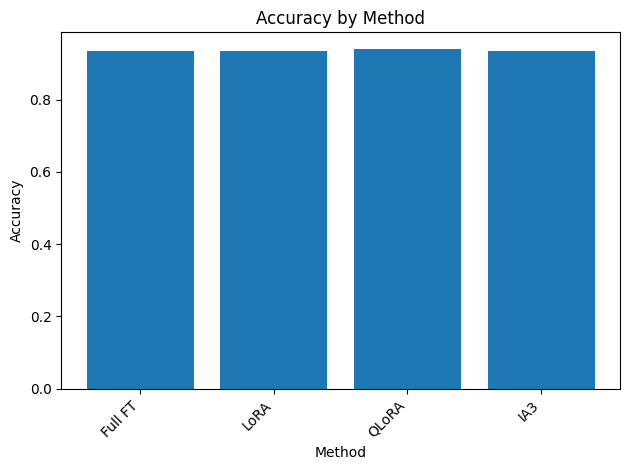

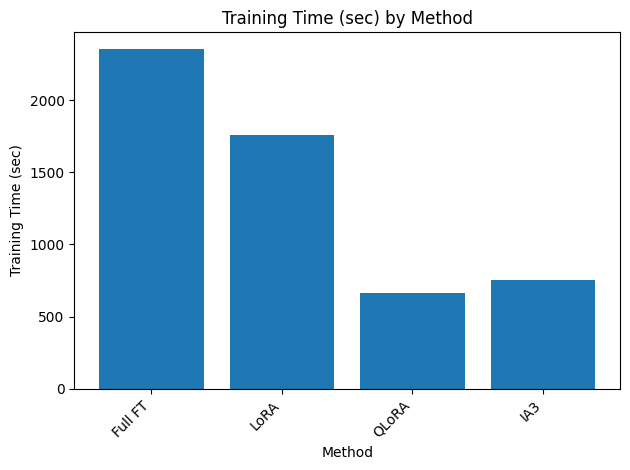

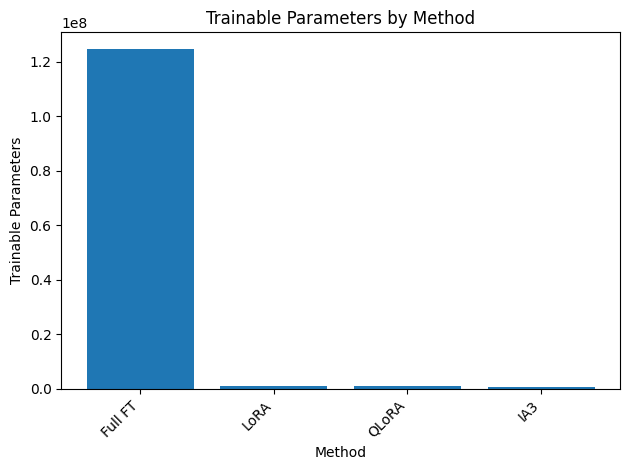

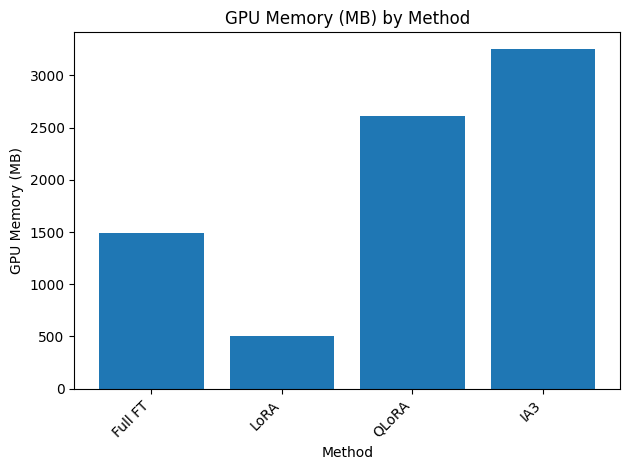

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Prepare your data
data = {
    "Method": ["Full FT", "LoRA", "QLoRA", "IA3"],
    "Accuracy": [0.9342, 0.9342, 0.9396, 0.9350],
    "Training Time (sec)": [2353.5, 1758.0, 665.8, 752.5],
    "Trainable Params": [124647170, 887042, 1034498, 665858],
    "GPU Memory (MB)": [1488.56, 503.14, 2609.10, 3250.40],
}

# 2) Create a DataFrame and print it
df = pd.DataFrame(data)
print("\n=== Comparison of Fine‑Tuning Methods ===")
print(df.to_markdown(index=False))

# 3) Plotting function
def plot_metric(metric, ylabel, filename=None):
    fig, ax = plt.subplots()
    ax.bar(df["Method"], df[metric])
    ax.set_title(f"{ylabel} by Method")
    ax.set_xlabel("Method")
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300)
    plt.show()

# 4) Generate all four bar charts
plot_metric("Accuracy",          "Accuracy")
plot_metric("Training Time (sec)", "Training Time (sec)", "training_time.png")
plot_metric("Trainable Params",  "Trainable Parameters",  "trainable_params.png")
plot_metric("GPU Memory (MB)",   "GPU Memory (MB)",       "gpu_memory.png")


## Part 5. Analysis and Discussion

### Summary  
Adapter‑based approaches (LoRA, QLoRA, IA³) achieve near—or in the case of QLoRA even surpass—full fine‑tuning accuracy while drastically reducing the number of trainable parameters and cutting training time. However, they trade off GPU memory differently: LoRA uses the least, QLoRA sits in the middle, and IA³ actually incurs the highest memory overhead despite having the fewest trainable parameters.  

---

### 1. Trade‑Off Analysis

- **Full Fine‑Tuning**  
  - **Accuracy**: 93.42%  
  - **Params & Compute**: 124 M trainable → highest GPU mem (~1.5 GB) and longest training (≈39 min).  
  - **When to Pick**: Only if you need end‑to‑end control over every weight (e.g., major domain shift).

- **LoRA**  
  - **Accuracy**: 93.42% (matches full FT)  
  - **Params & Compute**: ~0.9 M trainable → lowest GPU mem (~0.5 GB) and moderate training (≈29 min).  
  - **Strengths**: Extremely parameter‑efficient, ideal for edge or multi‑task settings.

- **QLoRA**  
  - **Accuracy**: 93.96% (highest)  
  - **Params & Compute**: ~1.0 M trainable → mid‑level GPU mem (~2.6 GB), fastest training (≈11 min).  
  - **Strengths**: Best accuracy‑vs‑time trade‑off; quantization makes it memory‑efficient for large models.

- **IA³**  
  - **Accuracy**: 93.50%  
  - **Params & Compute**: ~0.67 M trainable → highest GPU mem (~3.3 GB), fast training (≈12.5 min).  
  - **Strengths**: Minimal code‑surface changes and parameter updates, at the cost of extra inference memory.

---

### 2. Best Use Cases

| Method      | Ideal Scenario                                                                                     |
|-------------|-----------------------------------------------------------------------------------------------------|
| **Full FT** | Critical applications requiring full weight adaptation (e.g., major domain transfer, safety‑critical). |
| **LoRA**    | Deploying many task‑specific adapters on limited hardware (edge devices, multi‑tenant servers).      |
| **QLoRA**   | Prototyping or production where highest accuracy under tight time budgets is needed.                |
| **IA³**     | Rapid research iterations with minimal code changes when you can afford slightly more GPU memory.   |
